In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [2]:
df = pd.read_csv("country_year_modeling_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (5712, 12)


,iso3c,country,year,mmr,gdp_pc,health_exp_gdp,fertility,skilled_births,pm25,heat_index35_days,cooling_degree_days,disaster_exposure
0,AFE,Africa Eastern and Southern,2000,612.0,706.727261,5.657523,5.549893,40.977528,26.783513,0.0,3061.85,NaN
1,AFE,Africa Eastern and Southern,2001,586.0,625.827815,5.803267,5.501766,98.500000,26.809926,0.0,3255.66,NaN
2,AFE,Africa Eastern and Southern,2002,564.0,630.512328,5.408213,5.449696,98.900000,26.718091,0.0,3474.73,NaN
3,AFE,Africa Eastern and Southern,2003,537.0,815.432296,5.989670,5.407328,98.900000,26.580603,0.0,3506.74,NaN
4,AFE,Africa Eastern and Southern,2004,516.0,989.015464,6.069927,5.381308,98.500000,26.475208,0.0,3467.88,NaN


In [5]:
#sanity check
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Missing values:\n", df.isna().sum().sort_values(ascending=False).head(20))

# Basic target stats
print(df["mmr"].describe())

Year range: 2000 to 2023
Missing values:
 disaster_exposure      5474
pm25                    714
heat_index35_days       714
cooling_degree_days     714
skilled_births          238
iso3c                     0
country                   0
year                      0
mmr                       0
gdp_pc                    0
health_exp_gdp            0
fertility                 0
dtype: int64
count    5712.000000
mean      185.514006
std       250.643383
min         1.000000
25%        17.000000
50%        74.000000
75%       258.000000
max      1662.000000
Name: mmr, dtype: float64


In [7]:
#drop sparse features
if "disaster_exposure" in df.columns:
    df = df.drop(columns=["disaster_exposure"])

print("After dropping disaster_exposure:", df.shape)

After dropping disaster_exposure: (5712, 11)


In [9]:
#choose featureand impute missing predictors
features = [
    "gdp_pc",
    "health_exp_gdp",
    "fertility",
    "skilled_births",
    "pm25",
    "heat_index35_days",
    "cooling_degree_days"
]

#Keep only certain columns
features = [f for f in features if f in df.columns]
print("Using features:", features)

#Convert features + target to numeric safely
df["mmr"] = pd.to_numeric(df["mmr"], errors="coerce")
for f in features:
    df[f] = pd.to_numeric(df[f], errors="coerce")

#Drop rows missing target
df = df.dropna(subset=["mmr"]).copy()

#Impute missing predictors with year-median (defensible + simple)
df[features] = df.groupby("year")[features].transform(lambda s: s.fillna(s.median()))

#fill anything still missing
df[features] = df[features].fillna(df[features].median(numeric_only=True))

print("Remaining missing:\n", df[features + ["mmr"]].isna().sum())

Using features: ['gdp_pc', 'health_exp_gdp', 'fertility', 'skilled_births', 'pm25', 'heat_index35_days', 'cooling_degree_days']
Remaining missing:
 gdp_pc                 0
health_exp_gdp         0
fertility              0
skilled_births         0
pm25                   0
heat_index35_days      0
cooling_degree_days    0
mmr                    0
dtype: int64


In [11]:
#log transformation for target
df["log_mmr"] = np.log1p(df["mmr"])

print("Raw mmr summary:\n", df["mmr"].describe())
print("Log mmr summary:\n", df["log_mmr"].describe())

Raw mmr summary:
 count    5712.000000
mean      185.514006
std       250.643383
min         1.000000
25%        17.000000
50%        74.000000
75%       258.000000
max      1662.000000
Name: mmr, dtype: float64
Log mmr summary:
 count    5712.000000
mean        4.244341
std         1.552791
min         0.693147
25%         2.890372
50%         4.317488
75%         5.556828
max         7.416378
Name: log_mmr, dtype: float64


In [13]:
#time based train/test split
split_year = 2018

train = df[df["year"] <= split_year].copy()
test  = df[df["year"] > split_year].copy()

X_train = train[features]
y_train = train["log_mmr"]

X_test = test[features]
y_test = test["log_mmr"]

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (4522, 7) Test: (1190, 7)


In [15]:
#train models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,Model,MAE,RMSE,R2
2,Gradient Boosting,0.584727,0.748468,0.741286
1,Random Forest,0.579414,0.776394,0.721620
0,Linear Regression,0.680522,0.844597,0.670563


In [17]:
#convert back to mmr scale
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
preds_log = best_model.predict(X_test)

#Back-transform
preds_mmr = np.expm1(preds_log)
true_mmr  = np.expm1(y_test)

print("Best model:", best_model_name)
print("MAE on MMR scale:", mean_absolute_error(true_mmr, preds_mmr))
print("RMSE on MMR scale:", np.sqrt(mean_squared_error(true_mmr, preds_mmr)))

Best model: Gradient Boosting
MAE on MMR scale: 64.27316957288058
RMSE on MMR scale: 120.13564385475584


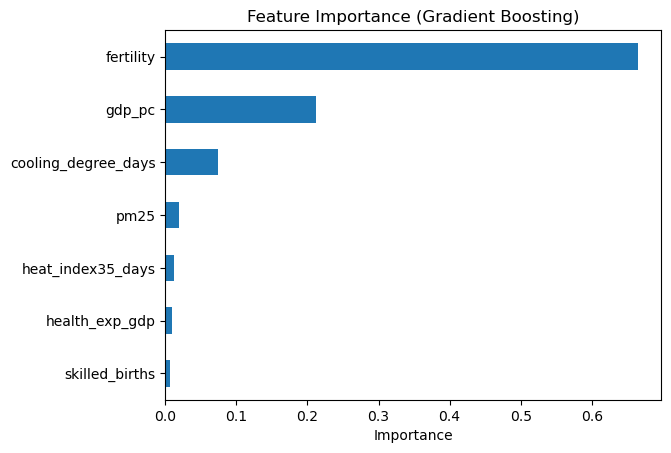

In [19]:
if best_model_name == "Gradient Boosting":
    importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
    importances.plot(kind="barh")
    plt.title("Feature Importance (Gradient Boosting)")
    plt.xlabel("Importance")
    plt.show()

In [21]:
df.to_csv("country_year_modeling_dataset_ready.csv", index=False)
print("Saved: country_year_modeling_dataset_ready.csv")

Saved: country_year_modeling_dataset_ready.csv
